In this notebook, we will use sklearn's LASSO for feature selection. This serves to simplify our dataset and improve interpretability.

In [102]:
#dependencies
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.optimize import minimize # for ensemble weight optimization
#for feature selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LassoCV, LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [103]:
# download LightGBM package
!pip install lightgbm

In [104]:
# download catboost package
!pip install catboost

In [105]:
# LGBM & catboost dependencies
import lightgbm as lgbm
from catboost import CatBoostRegressor
#from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV

In [106]:
# function for model evalaution in both log-price 'units' as well as natural units (USD dollar) 
def evaluate_model(y_true, y_pred_log):

    # TRUE VALUES IN LOG SPACE
    y_true_log = np.log1p(y_true)

    # BACK TRANSFORM PREDICTIONS
    y_pred = np.expm1(y_pred_log)

    # --- METRICS IN LOG SPACE ---
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    r2_log = r2_score(y_true_log, y_pred_log)
    mape_log = mean_absolute_percentage_error(y_true_log, y_pred_log)

    # --- METRICS IN PRICE SPACE ---
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    print("------ LOG METRICS ------")
    print("RMSE_log:", rmse_log)
    print("MAE_log:", mae_log)
    print("R2_log:", r2_log)
    print("MAPE_log:", mape_log)

    print("\n------ PRICE METRICS ($) ------")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)
    print("MAPE:", mape)

    return

In [215]:
train = pd.read_csv("train.csv")
val = pd.read_csv("val.csv")

#drop unnecessary features
UnneededFeatures = ['sale_date.1', 'maker_name_maker', 'is_ambiguous', 'candidate_count', 'location_filled', 'date', 'usd', 'gbp', 'eur', 'candidate_count', 'maker_name', 'lot', 'Day', 'gbp_usd_y', 'role']

train = train.drop(columns = UnneededFeatures)
valid = val.drop(columns = UnneededFeatures)

X_train = train.iloc[:, train.columns != 'price_usd_real']
X_valid = valid.iloc[:, train.columns != 'price_usd_real']
Y_train = train.iloc[:, train.columns == 'price_usd_real']
Y_valid = valid.iloc[:, train.columns == 'price_usd_real']

In [108]:
#log transforming target
train['log_price'] = np.log1p(train['price_usd_real'])
t=train.groupby('type')['log_price']

#groups each instrument type of the train set by its mean/median price
type_mean = train.groupby('type')['log_price'].mean()  
type_median = train.groupby('type')['log_price'].median()

type_mean.head()

type
Bass          9.835546
Bass Bow      7.830970
Bass Viol    11.087919
Cello        10.124304
Cello Bow     8.540933
Name: log_price, dtype: float64

We will temporarily create two new columns in the validation set to predict the price of each instrument sale using our means/medians above.

In [109]:
#check for missing values
print(X_train['type'].isna().any())
print(X_valid['type'].isna().any())

#creating new columns
valid['type_mean']= valid['type'].map(type_mean)
valid['type_median'] = valid['type'].map(type_median)
valid.head()

False
False


,sale_date,maker_id,type,city_maker,auction_house,bold_currency,Year,Month,cpi_usd,cpi_gbp,...,10y_yield_90d_change,MCI,real_price_gold,country_iso1,admin1_name,admin2_name,maker_last_name,birth_cent,type_mean,type_median
0,2000-02-14,2827,Violin,Paris,Phillip's,gbp,2000,2,0.522057,0.534901,...,0.00505,-6.037718,588.0587,FR,Île-de-France,Paris,Collin-Mézin,20.0,9.159512,8.991187
1,1995-11-14,356,Violin,Mirecourt,Bonhams,gbp,1995,11,0.472249,0.493020,...,-0.00120,4.018622,815.9887,FR,Grand Est,Vosges,Thibouville-Lamy,19.0,9.159512,8.991187
2,2008-10-07,185,Cello,Mantua,Sotheby's,gbp,2008,10,0.665862,0.641440,...,-0.00420,-4.978523,1331.5068,IT,Lombardy,Provincia di Mantova,Gadda,20.0,10.124304,10.062779
3,1993-05-23,1327,Viola,Vienna,Skinner,usd,1993,5,0.443349,0.467303,...,-0.00440,1.206404,851.0234,AT,Vienna,Wien Stadt,Huber,18.0,9.097133,9.065886
4,2010-10-10,524,Violin,Cremona,Skinner,usd,2010,10,0.672436,0.665687,...,-0.00790,3.251219,2002.1250,IT,Lombardy,Provincia di Cremona,Pedrazzini,19.0,9.159512,8.991187


# Model 0.1: Mean & Median Baseline Models

In [110]:
#evaluating base model
print("Base model: Predicting prices by mean and median of train set \n")
print("Mean")
evaluate_model(Y_valid, valid['type_mean'])

print("\n Median")
evaluate_model(Y_valid, valid['type_median'])

Base model: Predicting prices by mean and median of train set 

Mean
------ LOG METRICS ------
RMSE_log: 1.285456313665743
MAE_log: 0.988432919402884
R2_log: 0.10001861657415356
MAPE_log: 0.11279419733674426

------ PRICE METRICS ($) ------
RMSE: 125935.18437162781
MAE: 22152.072084267635
R2: -0.014001477146394548
MAPE: 1.5594670219204665

 Median
------ LOG METRICS ------
RMSE_log: 1.2931641897639936
MAE_log: 0.9841738236638584
R2_log: 0.0891932891990842
MAPE_log: 0.11087921033874927

------ PRICE METRICS ($) ------
RMSE: 126116.55690583902
MAE: 22118.01709392209
R2: -0.016924321211996718
MAPE: 1.3814586533054676


It is clear that predicting fine string instrument prices based on their instrument type alone is really unsuccessful because there are so many charactersitics/features that are not accounted for in this way, such as the maker who plays a hige role for the price, the instrument age, its condition, provenence and many more factors.

# Mode 0.2: Local Mean Model

In [111]:
def fit_baseline(train, min_count=1):
    """
    Compute mean prices on the training set.
    Returns three objects: maker_type_mean, type_mean, global_mean.
    min_count : minimum number of sales required to use the maker+type mean.
    """
    maker_type_stats = (
        train.groupby(['maker_id', 'type'])['log_price']
        .agg(['mean', 'count'])
    )
    maker_type_mean = (
        maker_type_stats[maker_type_stats['count'] >= min_count]['mean']
        .to_dict()
    )
    type_mean = t.mean().to_dict()

    return maker_type_mean, type_mean


def predict_baseline(df, maker_type_mean, type_mean):
    """
    For each row:
      1. Use the (maker_id, type) mean if >= min_count sales in train
      2. Otherwise use the type mean
    """
    preds = []
    for _, row in df.iterrows():
        key = (row['maker_id'], row['type'])
        if key in maker_type_mean:
            preds.append(maker_type_mean[key])
        elif row['type'] in type_mean:
            preds.append(type_mean[row['type']])
    return np.array(preds)

In [112]:
#  the prediction 
maker_type_mean, type_mean = fit_baseline(train)

y_pred = predict_baseline(valid, maker_type_mean, type_mean)

In [113]:
evaluate_model(Y_valid, y_pred)

------ LOG METRICS ------
RMSE_log: 0.7235277112568363
MAE_log: 0.5342694865235458
R2_log: 0.7148789897186255
MAPE_log: 0.06271652820481852

------ PRICE METRICS ($) ------
RMSE: 90880.64805801703
MAE: 13631.308149991059
R2: 0.47193515802333164
MAPE: 0.7896261917559948


In [114]:
#dropping columns we created for base model
valid = valid.drop(columns = ['type_mean', 'type_median'])
train = train.drop(columns = ['log_price'])

In [115]:
#collect categorical features
CategoricalCols = train.select_dtypes(include=["object", "bool"]).columns.tolist()

for x in CategoricalCols:
    print(f"{x} has {train[x].nunique()} unique values")

sale_date has 941 unique values
type has 14 unique values
city_maker has 628 unique values
auction_house has 27 unique values
bold_currency has 3 unique values
country_iso1 has 37 unique values
admin1_name has 164 unique values
admin2_name has 371 unique values
maker_last_name has 2164 unique values


C:\Users\Sean\AppData\Local\Temp\ipykernel_7516\4058123389.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  CategoricalCols = train.select_dtypes(include=["object", "bool"]).columns.tolist()


We will consider features with less that 20 unique values as "low cardinality", and the rest as "high cardinality".

In [209]:
LowCardCols = ["type", "bold_currency"]
#HighCardCols = ["sale_date", "maker_name", "city_maker", "auction_house", "lot", "country_iso1", "admin1_name", "admin2_name", "role", "maker_last_name"]
HighCardCols = ["sale_date", "city_maker", "auction_house", "country_iso1", "admin1_name", "admin2_name", "maker_last_name"]

In [117]:
#log transforming economic features
LogColumns = ['real_price_gold', 'SP500_real']

In [118]:
#features with numerical values
numberdtype = X_train.select_dtypes(include=[np.number]).columns.tolist()

#prevent overlap
NumericalCols = list( set(numberdtype) - set(LogColumns))


In [119]:
#impute with median and scale numerical columns
Numerical_transformer = Pipeline([
     ('imputer', SimpleImputer(strategy='median')), 
     ('scaler', StandardScaler() )
     ])

#impute and one hot encode low cardinality columns
OneHot_transformer = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value="other" )),
('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

#impute and target encode high cardinality columns
Target_transformer = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value="other")),
('target', TargetEncoder() )
])

#transform "log columns"
log_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, feature_names_out="one-to-one") ),
    ('scale', StandardScaler())
])



In [120]:
#this will apply our transformations
preprocessor = ColumnTransformer(
    transformers =[
        ('lognum', log_transformer, LogColumns),
        ('lowcard', OneHot_transformer, LowCardCols ),
        ('highcard', Target_transformer, HighCardCols ) ,
        ('num', Numerical_transformer, NumericalCols )],
        remainder = 'passthrough',
        sparse_threshold=0
)

# Model 1: Lasso-Regression

We can fit our data to a lasso regression pipeline with the same transformed columns. We can use this with the goal of feature selection and determining feature importance.

In [121]:
#lassocv with 10 cross validation folds
pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', LassoCV(cv=10))
])


lr = pipeline_lasso.fit(X_train,np.log1p(Y_train.values.ravel()))

In [122]:
#predictions in log prices
lasso_pred = lr.predict(X_valid)

print("Lassocv model evaluation: \n")
evaluate_model(Y_valid, lasso_pred)


#gives the optimal penalty determined by lassocv
optimal_alpha = pipeline_lasso.named_steps['lasso'].alpha_
print("\nOptimal alpha:", f"{optimal_alpha:.5f}")


Lassocv model evaluation: 

------ LOG METRICS ------
RMSE_log: 0.686519773324532
MAE_log: 0.5232751778570912
R2_log: 0.7433005232778558
MAPE_log: 0.06051999563392636

------ PRICE METRICS ($) ------
RMSE: 103034.44577907043
MAE: 14755.76495456704
R2: 0.32125084526034975
MAPE: 0.6819242753153527

Optimal alpha: 0.00119


In [123]:
#recovers the features transformed in the pipeline
preprocessor_lasso = pipeline_lasso.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

In [124]:
#gives coefficients used for each feature in regression
lasso_step = lr.named_steps['lasso']
coefficients = lasso_step.coef_

zerofeatures = []
nonzerofeatures = []

#setting a lower bound for a coefficient to be considered "nonzero"
epsilon = 1e-5

for i in range(len(feature_names)):
    if abs(coefficients[i]) < epsilon:
        zerofeatures.append(feature_names[i])
    else: nonzerofeatures.append(feature_names[i])

#the features with a coefficient of zero
for x in zerofeatures:
    print(x)


lognum__SP500_real
lowcard__type_Bass Viol
lowcard__type_Miscellaneous
lowcard__type_Tenor Viol
lowcard__type_Treble Viol
lowcard__type_Viola Bow
lowcard__type_Viola d'Amore
lowcard__bold_currency_usd
num__SP500_ma200
num__Year
num__SP500_vol_30d
num__cpi_usd
num__SP500_30d_ret
num__gbp_vol_30d


In [125]:
# feature and corresponding coefficient
lasso_coeffs = pd.DataFrame(index=feature_names, columns=['Lasso_Coeffs'])
lasso_coeffs.Lasso_Coeffs = coefficients
print('Non-zero Coefficient Features:')
lasso_coeffs.loc[nonzerofeatures, :]

Non-zero Coefficient Features:


,Lasso_Coeffs
lognum__real_price_gold,-0.023723
lowcard__type_Bass,0.054765
lowcard__type_Bass Bow,-0.011926
lowcard__type_Cello,0.835970
lowcard__type_Cello Bow,-0.047677
lowcard__type_Small Violin,-0.314703
lowcard__type_Viola,0.074923
lowcard__type_Violin,0.015138
lowcard__type_Violin Bow,-0.143624
lowcard__bold_currency_eur,-0.018340


In [126]:
#shows the different alphas selected by lassocv
alphas =lasso_step.alphas_
print(alphas)


[1.19032746 1.11010337 1.03528612 0.9655113  0.90043907 0.83975249
 0.78315598 0.73037389 0.68114914 0.63524196 0.59242878 0.55250106
 0.51526434 0.48053725 0.44815065 0.41794679 0.38977858 0.36350881
 0.33900953 0.31616142 0.2948532  0.27498108 0.25644828 0.23916452
 0.22304563 0.2080131  0.19399372 0.18091919 0.16872584 0.15735428
 0.14674913 0.13685873 0.12763491 0.11903275 0.11101034 0.10352861
 0.09655113 0.09004391 0.08397525 0.0783156  0.07303739 0.06811491
 0.0635242  0.05924288 0.05525011 0.05152643 0.04805372 0.04481506
 0.04179468 0.03897786 0.03635088 0.03390095 0.03161614 0.02948532
 0.02749811 0.02564483 0.02391645 0.02230456 0.02080131 0.01939937
 0.01809192 0.01687258 0.01573543 0.01467491 0.01368587 0.01276349
 0.01190327 0.01110103 0.01035286 0.00965511 0.00900439 0.00839752
 0.00783156 0.00730374 0.00681149 0.00635242 0.00592429 0.00552501
 0.00515264 0.00480537 0.00448151 0.00417947 0.00389779 0.00363509
 0.0033901  0.00316161 0.00294853 0.00274981 0.00256448 0.0023

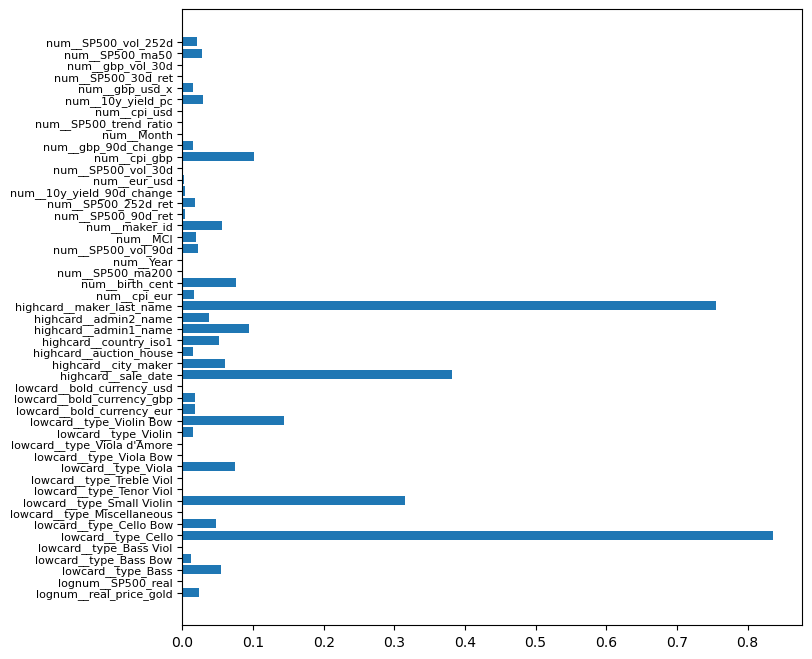

In [127]:
plt.figure(figsize=(8,8))

abs_coefficients = [abs(x) for x in coefficients]
plt.barh(feature_names, abs_coefficients)
plt.tight_layout
plt.yticks(fontsize=8)
plt.show()

Here we see that many different features all carry predictive power: the instrument type is especially crucial for price prediction bt so is the instrument maker. In addition to that the enhanced features that were created especially for this data set seem to have good predictive power. Those are the economic features based, e.g., on the stock market indices, as well as the geographical information inferred for each instrument.

# Model 2: Random Forest

In [216]:
#creates a pipeline object
pipeline_randomforest = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=0))
])
#fits our data to the pipeline/model with log transformed target
rf = pipeline_randomforest.fit(X_train,np.log1p(Y_train))

forest_pred_log = rf.predict(X_valid)

evaluate_model(Y_valid, forest_pred_log)

c:\Users\Sean\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Sean\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


------ LOG METRICS ------
RMSE_log: 0.6370030335680685
MAE_log: 0.48220279024756674
R2_log: 0.7789951097088629
MAPE_log: 0.05602858556791657

------ PRICE METRICS ($) ------
RMSE: 77570.09494816184
MAE: 12488.12698100207
R2: 0.6152903598685248
MAPE: 0.6184649169628463


# Model 3: LightGBM

Define the Model with default parameters.

In [129]:
lgbm_model = lgbm.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose = -1
)

In [130]:
pipeline_lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgbm_model)])

Use cross-validation to find the best model via a grid-search.

In [131]:
'''param_grid = {
    "model__num_leaves": [80, 100, 120, 140],
    "model__learning_rate": [0.005, 0.007, 0.009],
    "model__n_estimators": [800, 900, 1000],
    "model__max_depth": [-1]
}'''
# this parameter grid has already been narrowed down in many iterations of running the algo
param_grid = {
    "model__num_leaves": [62, 63, 64], # best 63
    "model__learning_rate": [0.01, 0.011], # best 0.011
    "model__n_estimators": [2300, 2500, 2700, 2900], # best 2300
    "model__max_depth": [-1]
}


search_lgbm = RandomizedSearchCV(
    pipeline_lgbm,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_iter=20,
    n_jobs=-1,
    verbose=1
)

In [132]:
search_lgbm.fit(X_train, np.log1p(Y_train.values.ravel()))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.011], 'model__max_depth': [-1], 'model__n_estimators': [2300, 2500, ...], 'model__num_leaves': [62, 63, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation s

In [137]:
best_lgbm = search_lgbm.best_estimator_
print(search_lgbm.best_params_)

{'model__num_leaves': 62, 'model__n_estimators': 2500, 'model__max_depth': -1, 'model__learning_rate': 0.011}


### Prediction

In [138]:
y_pred_log_lgbm = best_lgbm.predict(X_valid)
#y_pred_lgbm = np.expm1(y_pred_log_lgbm)

c:\Users\Sean\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [140]:
evaluate_model(Y_valid, y_pred_log_lgbm)

------ LOG METRICS ------
RMSE_log: 0.6121829454798254
MAE_log: 0.4650791030664713
R2_log: 0.7958819852305699
MAPE_log: 0.05396108720486328

------ PRICE METRICS ($) ------
RMSE: 83664.93763215773
MAE: 12707.702354399267
R2: 0.5524604649902111
MAPE: 0.590377137772312


In [141]:
evaluate_model(Y_valid, y_pred_log_lgbm)

------ LOG METRICS ------
RMSE_log: 0.6121829454798254
MAE_log: 0.4650791030664713
R2_log: 0.7958819852305699
MAPE_log: 0.05396108720486328

------ PRICE METRICS ($) ------
RMSE: 83664.93763215773
MAE: 12707.702354399267
R2: 0.5524604649902111
MAPE: 0.590377137772312


# Model 4: CatBoost

In [142]:
y_train_log = np.log1p(Y_train.squeeze())
y_valid_log = np.log1p(Y_valid.squeeze())

cat_model = CatBoostRegressor(
    loss_function='RMSE',
    random_seed=42,
    verbose=0)

pipeline_cat = Pipeline([("preprocessor", preprocessor), ("model", cat_model)])

'''param_dist = {
    "model__iterations": [2000,3000,4000], #best was 2000
    "model__learning_rate": [0.01,0.02,0.03], #best was 0.03
    "model__depth": [10, 12, 15], #best was 10
    "model__l2_leaf_reg": [20], #best was 20
    "model__min_data_in_leaf": [5], #best was 5
}'''
param_dist = {
    "model__iterations": [2000], #best was 2000
    "model__learning_rate": [0.03], #best was 0.03
    "model__depth": [10], #best was 10
    "model__l2_leaf_reg": [20], #best was 20
    "model__min_data_in_leaf": [5], #best was 5
}

search_cat = RandomizedSearchCV(
    pipeline_cat,
    param_distributions=param_dist,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_iter=20,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

In [143]:
search_cat.fit(X_train, y_train_log)

best_cat = search_cat.best_estimator_
print("Best CatBoost params:", search_cat.best_params_)

c:\Users\Sean\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 1 is smaller than n_iter=20. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best CatBoost params: {'model__min_data_in_leaf': 5, 'model__learning_rate': 0.03, 'model__l2_leaf_reg': 20, 'model__iterations': 2000, 'model__depth': 10}


In [144]:
y_pred_log_cat = best_cat.predict(X_valid)

evaluate_model(Y_valid.squeeze(), y_pred_log_cat)

------ LOG METRICS ------
RMSE_log: 0.6113113998558105
MAE_log: 0.4636713387392602
R2_log: 0.7964627643256275
MAPE_log: 0.05381276109412699

------ PRICE METRICS ($) ------
RMSE: 94139.20710610013
MAE: 13091.843075884735
R2: 0.43338835585992286
MAPE: 0.5835762983705376


In [145]:
y_pred_log_cat = best_cat.predict(X_valid)

evaluate_model(Y_valid.squeeze(), y_pred_log_cat)

------ LOG METRICS ------
RMSE_log: 0.6113113998558105
MAE_log: 0.4636713387392602
R2_log: 0.7964627643256275
MAPE_log: 0.05381276109412699

------ PRICE METRICS ($) ------
RMSE: 94139.20710610013
MAE: 13091.843075884735
R2: 0.43338835585992286
MAPE: 0.5835762983705376


# Model(s) 5: Ensemble Method
In this section we will combine (in various ways) the predictions of the three performant model (Random Forest, LGBM, CatBoost) in order to determine whether a combination of the models performs better than each one alone.

In [146]:
# stack all the predictions that ought be used in the ensemble
X_ensemble = np.column_stack([
    forest_pred_log,
    y_pred_log_lgbm,
    y_pred_log_cat
])

## Naive Ensemble

In [147]:
y_pred_avg = X_ensemble.mean(axis=1)

In [148]:
evaluate_model(Y_valid, y_pred_avg)

------ LOG METRICS ------
RMSE_log: 0.6097884845234366
MAE_log: 0.46277913309096497
R2_log: 0.7974756159565188
MAPE_log: 0.05375775997601627

------ PRICE METRICS ($) ------
RMSE: 84404.9651711404
MAE: 12615.506664004151
R2: 0.5445083572860558
MAPE: 0.5858628081181686


## Weighted Ensemble
We find the optimal ensemble weights via optimization with a RMSE loss for weighting the models linearly, which is implemented through an additional Ridge Regression. This means the ensemble prediction is a omptimized linear combination of the 3 input model predictions. 

In [ ]:
def rmse_loss(weights):
    weights = weights / weights.sum()  # normalize weights, such that they sum to 1
    y_pred = np.dot(X_ensemble, weights)
    return np.sqrt(mean_squared_error(y_valid_log, y_pred))

# initial equal weights
init_weights = np.array([1/3, 1/3, 1/3])

# constraint: weights sum to 1
constraints = {'type': 'eq', 'fun': lambda w: w.sum() - 1}

# bounds: weights between 0 and 1
bounds = [(0, 1)] * 3

result = minimize(rmse_loss, init_weights, bounds=bounds, constraints=constraints) # scipy numerical optimizer

optimal_weights = result.x / result.x.sum()
print("Optimal weights:", optimal_weights)

Optimal weights: [0.        0.4866936 0.5133064]


In [176]:
meta_model = Ridge(alpha=1)
meta_model.fit(X_ensemble, y_valid_log)

y_pred_stacked = meta_model.predict(X_ensemble)

print("Stacking coefficients:", meta_model.coef_)

Stacking coefficients: [0.10278275 0.41344027 0.49530139]


In [91]:
evaluate_model(Y_valid, y_pred_stacked)

------ LOG METRICS ------
RMSE_log: 0.5879901174371883
MAE_log: 0.4460433732295467
R2_log: 0.8116962642206067
MAPE_log: 0.051848466549446595

------ PRICE METRICS ($) ------
RMSE: 81476.44131411426
MAE: 11661.948581451665
R2: 0.5755676025612575
MAPE: 0.5604766606006077


# Error Analysis

In [149]:
def error_analysis_report(
    X,
    y_true_raw,
    y_pred_log,
    location_col="location_filled",
    type_col="type",
    country_col="country_iso1",
    price_outlier_q=0.99,
    error_outlier_q=0.95,
    min_group_size=20,
    top_n_countries=15,
    top_n_worst_rows=25
):
    """
    Analyse d'erreur pour un modèle entraîné sur log1p(price).
    """

    X = X.copy().reset_index(drop=True)
    y_true_raw = pd.Series(np.asarray(y_true_raw).reshape(-1), name="y_true_raw").reset_index(drop=True)
    y_pred_log = pd.Series(np.asarray(y_pred_log).reshape(-1), name="y_pred_log").reset_index(drop=True)

    if not (len(X) == len(y_true_raw) == len(y_pred_log)):
        raise ValueError("X, y_true_raw, et y_pred_log doivent avoir la même longueur.")

    df = X.copy()
    df["y_true_raw"] = y_true_raw
    df["y_true_log"] = np.log1p(y_true_raw.clip(lower=0))
    df["y_pred_log"] = y_pred_log
    df["y_pred_raw"] = np.expm1(y_pred_log)

    # Calcul des erreurs
    df["error_raw"] = df["y_pred_raw"] - df["y_true_raw"]
    df["abs_error_raw"] = df["error_raw"].abs()

    denom = np.maximum(df["y_true_raw"].to_numpy(), 1.0)
    df["pct_error"] = 100.0 * df["error_raw"] / denom
    df["abs_pct_error"] = df["pct_error"].abs()

    df["error_log"] = df["y_pred_log"] - df["y_true_log"]
    df["abs_error_log"] = df["error_log"].abs()

    # Détection des outliers
    price_cut = df["y_true_raw"].quantile(price_outlier_q)
    err_cut = df["abs_error_log"].quantile(error_outlier_q)

    df["price_outlier"] = df["y_true_raw"] >= price_cut
    df["error_outlier"] = df["abs_error_log"] >= err_cut

    df["outlier_bucket"] = np.select(
        [
            df["price_outlier"] & df["error_outlier"],
            df["price_outlier"] & ~df["error_outlier"],
            ~df["price_outlier"] & df["error_outlier"],
        ],
        [
            "price_and_error_outlier",
            "price_outlier_only",
            "error_outlier_only",
        ],
        default="neither"
    )

    # Fonction interne pour calculer les métriques par groupe
    def summarize(g):
        return pd.Series({
            "count": len(g),
            "rmse_raw": np.sqrt(np.mean(g["error_raw"] ** 2)),
            "mae_raw": np.mean(g["abs_error_raw"]),
            "rmse_log": np.sqrt(np.mean(g["error_log"] ** 2)),
            "mae_log": np.mean(g["abs_error_log"]),
            "mean_abs_pct_error": np.mean(g["abs_pct_error"]),
            "median_abs_pct_error": np.median(g["abs_pct_error"]),
            "mean_bias_raw": np.mean(g["error_raw"]),
            "mean_bias_log": np.mean(g["error_log"]),
            "share_abs_pct_over_25": np.mean(g["abs_pct_error"] > 25),
            "share_abs_pct_over_50": np.mean(g["abs_pct_error"] > 50),
        })

    overall_summary = summarize(df).to_frame().T

    # Résumé par localisation
    if location_col in df.columns:
        location_summary = (
            df.groupby(location_col, dropna=False)
            .apply(summarize)
            .reset_index()
            .sort_values("count", ascending=False)
        )
    else:
        location_summary = None
        print(f"Colonne '{location_col}' non trouvée ; analyse de localisation ignorée.")

    # Résumé des outliers
    price_outlier_summary = df.groupby("price_outlier", dropna=False).apply(summarize).reset_index()
    error_outlier_summary = df.groupby("error_outlier", dropna=False).apply(summarize).reset_index()
    outlier_bucket_summary = (
        df.groupby("outlier_bucket", dropna=False)
        .apply(summarize)
        .reset_index()
        .sort_values("count", ascending=False)
    )

    # Résumé par type
    if type_col in df.columns:
        type_summary = (
            df.groupby(type_col, dropna=False)
            .apply(summarize)
            .reset_index()
            .sort_values("count", ascending=False)
        )
        type_summary = type_summary[type_summary["count"] >= min_group_size].copy()
    else:
        type_summary = None
        print(f"Colonne '{type_col}' non trouvée ; analyse par type ignorée.")

    # Résumé par pays
    if country_col in df.columns:
        country_summary = (
            df.groupby(country_col, dropna=False)
            .apply(summarize)
            .reset_index()
            .sort_values("count", ascending=False)
        )
        country_summary = country_summary[country_summary["count"] >= min_group_size].copy()
        country_summary = country_summary.head(top_n_countries).copy()
    else:
        country_summary = None
        print(f"Colonne '{country_col}' non trouvée ; analyse par pays ignorée.")

    # Extraction des pires lignes pour inspection
    inspect_cols = [c for c in [type_col, country_col, location_col, "maker_name", "maker_last_name", "sale_date"] if c in df.columns]
    worst_rows = (
        df[inspect_cols + [
            "y_true_raw", "y_pred_raw", "error_raw", "abs_error_raw",
            "pct_error", "abs_pct_error", "y_true_log", "y_pred_log",
            "error_log", "abs_error_log", "price_outlier", "error_outlier", "outlier_bucket"
        ]]
        .sort_values("abs_error_log", ascending=False)
        .head(top_n_worst_rows)
        .copy()
    )

    # ---------- Visualisation ----------
    def plot_bar(summary_df, group_col, metric_col, title):
        if summary_df is None or summary_df.empty:
            return
        plot_df = summary_df.sort_values(metric_col, ascending=False).copy()
        labels = plot_df[group_col].astype(str)

        plt.figure(figsize=(max(8, 0.55 * len(plot_df) + 2), 5))
        plt.bar(labels, plot_df[metric_col])
        plt.title(title)
        plt.ylabel(metric_col)
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    def plot_boolean_group(summary_df, group_col, metric_col, title):
        if summary_df is None or summary_df.empty:
            return
        labels = summary_df[group_col].astype(str)

        plt.figure(figsize=(6, 4))
        plt.bar(labels, summary_df[metric_col])
        plt.title(title)
        plt.ylabel(metric_col)
        plt.tight_layout()
        plt.show()

    # Affichage des graphiques
    if location_summary is not None:
        plot_boolean_group(location_summary, location_col, "median_abs_pct_error", f"Median absolute % error by {location_col}")
        plot_boolean_group(location_summary, location_col, "rmse_log", f"Log-RMSE by {location_col}")

    plot_boolean_group(price_outlier_summary, "price_outlier", "median_abs_pct_error", "Median absolute % error: price outliers vs non-outliers")
    plot_boolean_group(error_outlier_summary, "error_outlier", "median_abs_pct_error", "Median absolute % error: error outliers vs non-outliers")

    if type_summary is not None:
        plot_bar(type_summary, type_col, "median_abs_pct_error", f"Median absolute % error by {type_col}")

    if country_summary is not None:
        plot_bar(country_summary, country_col, "median_abs_pct_error", f"Median absolute % error by {country_col} (top {top_n_countries} by count)")

    results = {
        "row_level_df": df,
        "overall_summary": overall_summary,
        "location_summary": location_summary,
        "price_outlier_summary": price_outlier_summary,
        "error_outlier_summary": error_outlier_summary,
        "outlier_bucket_summary": outlier_bucket_summary,
        "type_summary": type_summary,
        "country_summary": country_summary,
        "worst_rows": worst_rows,
        "price_outlier_cutoff": price_cut,
        "error_outlier_cutoff_abs_log_error": err_cut,
    }

    return results

In [150]:
# 2. Appeler la fonction
results = error_analysis_report(
    X=X_valid,
    y_true_raw=Y_valid,
    y_pred_log=cat_pred,
    location_col="admin1_name", # Assure-toi que cette colonne existe dans X_test
    type_col="type",
    country_col="country_iso1"
)

NameError: name 'cat_pred' is not defined

In [70]:
# Fonction modifiée pour inclure le top N et l'ordre décroissant
def plot_bar_improved(summary_df, group_col, metric_col, title, top_n=None):
    if summary_df is None or summary_df.empty:
        return
    
    # Copie pour ne pas modifier l'original
    plot_df = summary_df.copy()
    
    # Trier par métrique pour placer les pires erreurs en premier
    plot_df = plot_df.sort_values(metric_col, ascending=False)
    
    # Sélectionner le top N (par exemple 10)
    if top_n is not None:
        plot_df = plot_df.head(top_n)
        if title:
            title = f"{title} (Top {top_n})"
    
    labels = plot_df[group_col].astype(str)
    
    # Ajuster la taille de la figure en fonction du nombre de barres
    plt.figure(figsize=(max(8, 0.6 * len(plot_df)), 5))
    
    # Créer les barres
    bars = plt.bar(labels, plot_df[metric_col])
    
    plt.title(title)
    plt.ylabel(metric_col)
    
    # Améliorer les étiquettes de l'axe X
    plt.xticks(rotation=45, ha="right")
    
    # Optionnel : ajouter les valeurs au-dessus des barres
    # pour une lecture plus précise
    # for bar in bars:
    #     height = bar.get_height()
    #     plt.text(bar.get_x() + bar.get_width() / 2, height,
    #              f'{height:.1f}',
    #              ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# Exemple d'appel pour votre cas spécifique
# Supposons que 'region_summary' contient vos résultats de groupby par admin1_name

# Au lieu d'appeler votre ancienne fonction, appelez la nouvelle :
# plot_bar_improved(
#     region_summary,       # Votre DataFrame de résumé
#     'admin1_name',        # La colonne de groupe
#     'median_abs_pct_error', # La métrique
#     'Erreur médiane par région', # Le titre de base
#     top_n=10              # Paramètre ajouté
# )

In [217]:
test = pd.read_csv("test.csv")


In [218]:
test = test.drop(columns = UnneededFeatures)

In [219]:

X_test = test.iloc[:, test.columns != 'price_usd_real']
Y_test = test.iloc[:, test.columns == 'price_usd_real']

We will now evaluate all of our models on the test set.

In [234]:
print("\nBase model:\n")
y_pred_test = predict_baseline(test, maker_type_mean, type_mean)

evaluate_model(Y_test, y_pred_test)

forest_pred_log_test = rf.predict(X_test)

print("\nRandom forest: \n")
evaluate_model(Y_test, forest_pred_log_test)






Base model:

------ LOG METRICS ------
RMSE_log: 0.7101023422008216
MAE_log: 0.5255230116236331
R2_log: 0.7117453923738049
MAPE_log: 0.06162184821265707

------ PRICE METRICS ($) ------
RMSE: 162882.68782914992
MAE: 12688.622319761727
R2: 0.18858149499823895
MAPE: 0.7502248230914841

Random forest: 

------ LOG METRICS ------
RMSE_log: 0.6387985003433528
MAE_log: 0.4851373347098767
R2_log: 0.7667282520668077
MAPE_log: 0.0562660031181496

------ PRICE METRICS ($) ------
RMSE: 145839.79094316528
MAE: 12029.032640367312
R2: 0.3495002716622153
MAPE: 0.6067999955708732


In [236]:
lasso_pred_test = lr.predict(X_test)

print("\nLassocv:\n")
evaluate_model(Y_test, lasso_pred_test)

print("\nlgbm:\n")
y_pred_log_lgbm_test = best_lgbm.predict(X_test)

evaluate_model(Y_test, y_pred_log_lgbm_test)

print("\nCatboost:\n")
y_pred_log_cat_test = best_cat.predict(X_test)

evaluate_model(Y_test, y_pred_log_cat_test)






Lassocv:

------ LOG METRICS ------
RMSE_log: 0.6879494881426371
MAE_log: 0.5255534342973934
R2_log: 0.7294500415955333
MAPE_log: 0.06063482216362458

------ PRICE METRICS ($) ------
RMSE: 171321.3367677382
MAE: 14132.19070657867
R2: 0.10232741470641127
MAPE: 0.6723607868108016

lgbm:



c:\Users\Sean\anaconda3\envs\erdos_ds_environment\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


------ LOG METRICS ------
RMSE_log: 0.6135097013742491
MAE_log: 0.4694524158415546
R2_log: 0.7848322210439986
MAPE_log: 0.054387653945914376

------ PRICE METRICS ($) ------
RMSE: 149457.10305531492
MAE: 11977.739536335994
R2: 0.31683096520397025
MAPE: 0.5697328686612161

Catboost:

------ LOG METRICS ------
RMSE_log: 0.6106004919260225
MAE_log: 0.467263224242743
R2_log: 0.7868679964880259
MAPE_log: 0.054111583410925736

------ PRICE METRICS ($) ------
RMSE: 160981.8245682365
MAE: 12252.235495877676
R2: 0.20740971623882465
MAPE: 0.5643460873945223


In [237]:
X_ensemble_test = np.column_stack([
    forest_pred_log_test,
    y_pred_log_lgbm_test,
    y_pred_log_cat_test
])

y_pred_avg_test = X_ensemble_test.mean(axis=1)
print("Naive ensemble method:\n")
evaluate_model(Y_test, y_pred_avg_test)



y_pred_stacked_test = meta_model.predict(X_ensemble_test)
print("\nWeighted ensemble method:\n")
evaluate_model(Y_test, y_pred_stacked_test)

Naive ensemble method:

------ LOG METRICS ------
RMSE_log: 0.6104539504133029
MAE_log: 0.46618524046745025
R2_log: 0.7869702857549388
MAPE_log: 0.05404545556988229

------ PRICE METRICS ($) ------
RMSE: 152964.91487471177
MAE: 11921.680285652823
R2: 0.28438619165235324
MAPE: 0.5664922062835548

Weighted ensemble method:

------ LOG METRICS ------
RMSE_log: 0.6079746636510912
MAE_log: 0.46472848210842205
R2_log: 0.7886971620140979
MAPE_log: 0.053847950430729145

------ PRICE METRICS ($) ------
RMSE: 154365.43698860903
MAE: 11969.757144983363
R2: 0.27122211273674046
MAPE: 0.5630820237163702


Colonne 'location_filled' non trouvée ; analyse de localisation ignorée.


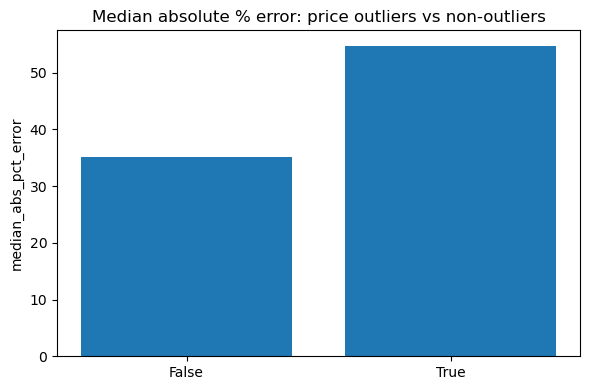

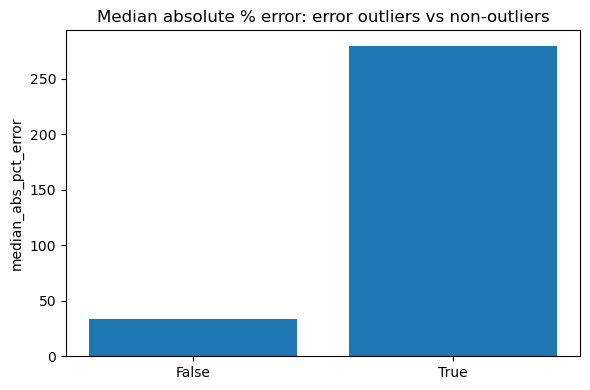

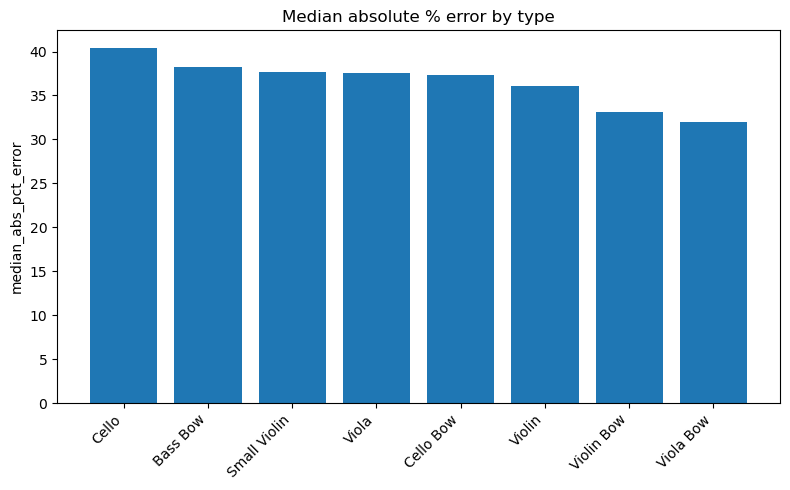

TypeError: 'value' must be an instance of str or bytes, not a float

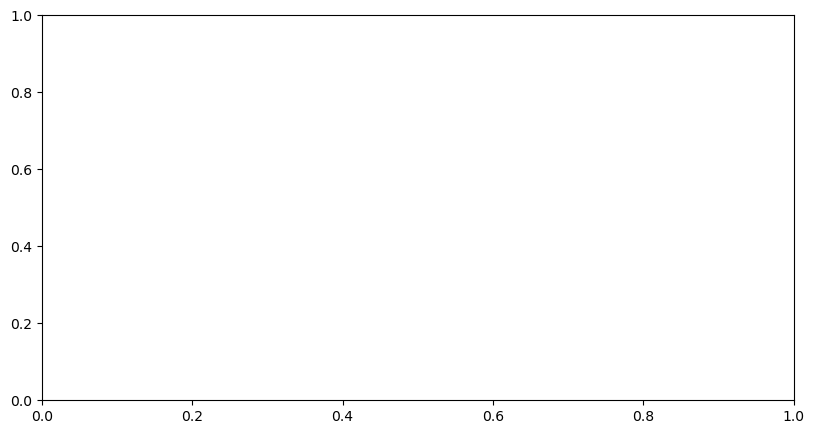

In [223]:
error_results = error_analysis_report(X_test, Y_test, y_pred_log_cat_test )